In [ ]:
from keras import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

plt.rcParams['font.family'] = 'Malgun Gothic'

In [ ]:
imageGen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.5,
    brightness_range=[0.5,1.5],
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=30,
    fill_mode='nearest',
    validation_split=0.2
)

# Train
trainGen = imageGen.flow_from_directory(
    'landscape/seg_train/seg_train',
    target_size=(100,100),
    subset='training',
    shuffle=False
)

# Validation
valGen = imageGen.flow_from_directory(
    'landscape/seg_train/seg_train',
    target_size=(100,100),
    subset='validation',
    shuffle=False
)

# Test
testGen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'landscape/seg_test/seg_test',
    target_size=(100,100),
    shuffle=False
)

---
CNN

In [ ]:
model = Sequential()
model.add( Conv2D( 64, kernel_size=(2,2),
                   input_shape=(100,100,3), activation='relu') )
model.add( MaxPool2D( pool_size=(2,2) ) )
model.add( Conv2D( 32, kernel_size=(3,3), activation='relu' ) )
model.add( MaxPool2D( pool_size=(2,2)) )

model.add( Flatten() )
model.add( Dense(units=64, activation='relu') )
model.add( Dense(units=32, activation='relu') )
model.add( Dense(units=6, activation='softmax') )

model.compile( loss='categorical_crossentropy', optimizer='Adam', metrics=['acc'] )
history = model.fit(trainGen, epochs=30, validation_data=valGen)

c:\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - acc: 0.4840 - loss: 1.2627 - val_acc: 0.5856 - val_loss: 1.0648
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - acc: 0.6037 - loss: 1.0255 - val_acc: 0.5770 - val_loss: 1.0874
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 53s 151ms/step - acc: 0.6289 - loss: 0.9558 - val_acc: 0.6772 - val_loss: 0.8921
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - acc: 0.6602 - loss: 0.8913 - val_acc: 0.6954 - val_loss: 0.8499
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - acc: 0.6801 - loss: 0.8594 - val_acc: 0.6776 - val_loss: 0.8688
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - acc: 0.6890 - loss: 0.8297 - val_acc: 0.7040 - val_loss: 0.8004
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - acc: 0.7010 - loss: 0.8014 - val_acc: 0.7047 - val_loss: 0.7960
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - acc: 0.7097 - loss: 0.7803 - val_acc: 0.7165 - val_loss: 0.7608
Epoch 9/30
351/351 ━━━━━━━━━━━━━

351/351 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step
TRAIN Accuracy: 0.7894033837934105
TRAIN F1 Score: 0.7899170825466094


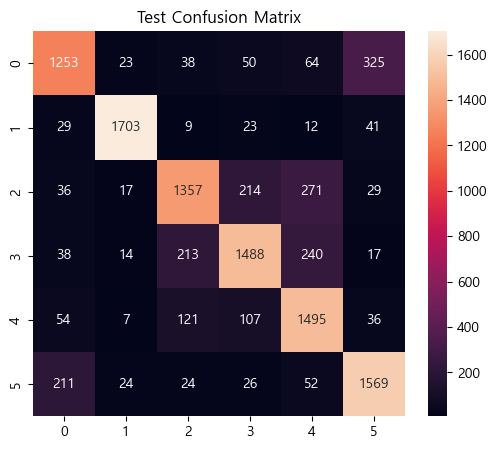

In [68]:
trainGen.shuffle = False
train_pred = model.predict(trainGen)
train_pred_labels = np.argmax(train_pred, axis=1)
train_true_labels = trainGen.classes

train_acc = accuracy_score(train_true_labels, train_pred_labels)
train_f1 = f1_score(train_true_labels, train_pred_labels, average='macro')

print("TRAIN Accuracy:", train_acc)
print("TRAIN F1 Score:", train_f1)
cm_test = confusion_matrix(train_true_labels, train_pred_labels)
plt.figure(figsize=(6,5))
sb.heatmap(cm_test, annot=True, fmt='d')
plt.title("Test Confusion Matrix")
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
TEST Accuracy: 0.7816666666666666
TEST F1 Score: 0.7807030191206404


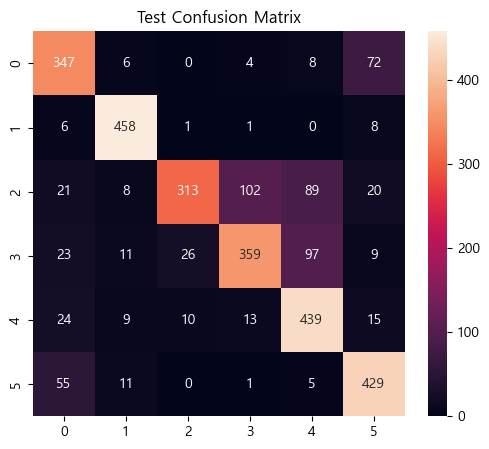

In [69]:
test_pred = model.predict(testGen)
test_pred_labels = np.argmax(test_pred, axis=1)
test_true_labels = testGen.classes

test_acc = accuracy_score(test_true_labels, test_pred_labels)
test_f1 = f1_score(test_true_labels, test_pred_labels, average='macro')

print("TEST Accuracy:", test_acc)
print("TEST F1 Score:", test_f1)

cm_test = confusion_matrix(test_true_labels, test_pred_labels)
plt.figure(figsize=(6,5))
sb.heatmap(cm_test, annot=True, fmt='d')
plt.title("Test Confusion Matrix")
plt.show()

---

In [73]:
trainGen.class_indices

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

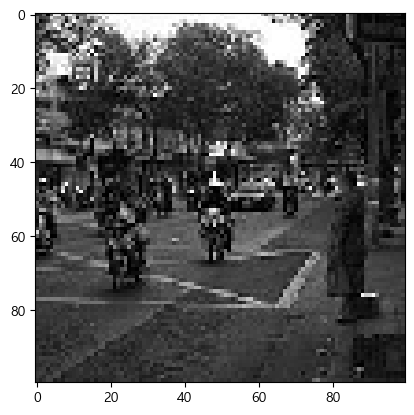

In [54]:
s_img = load_img('landscape/seg_pred/seg_pred/3.jpg', target_size=(100,100))
imgArr = img_to_array(s_img) /255
plt.imshow(imgArr)
plt.show()

In [55]:
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


array([5])

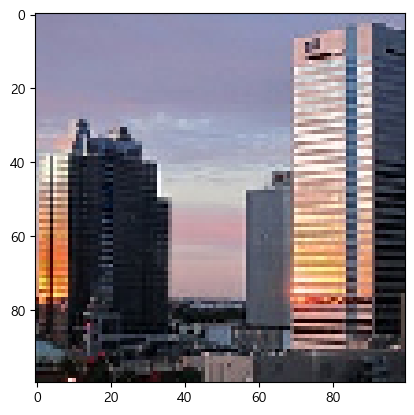

In [70]:
s_img = load_img('landscape/seg_pred/seg_pred/5.jpg', target_size=(100,100))
imgArr = img_to_array(s_img) /255
plt.imshow(imgArr)
plt.show()

In [71]:
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([0])